# **Title : Customer Segmentation and Product Recommendation System Using Machine Learning**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
#Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
#Save models
import pickle
#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("online_retail.csv")

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


**lowercase columns**

In [6]:
df.columns = ["invoice_no",
              "stock_code",
              "description",
              "quantity",
              "invoice_date",
              "unit_price",
              "customer_id",
              "country"]
print(df.columns)

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='object')


In [7]:
df = df.drop_duplicates()

**Checking nulls**

In [8]:
print(df.isnull().sum())

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135037
country              0
dtype: int64


**Removing Null Values**

In [9]:
df = df.dropna(subset=['customer_id'])

In [10]:
df = df.dropna(subset=['description'])

**converting customer id to integer**

In [11]:
df['customer_id']= df['customer_id'].astype(int)

**Converting Invoice Date**

In [12]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

In [13]:
print(df["invoice_date"].head())
print(df["invoice_date"].dtype)
print(df["invoice_date"].isna().sum())

0   2022-12-01 08:26:00
1   2022-12-01 08:26:00
2   2022-12-01 08:26:00
3   2022-12-01 08:26:00
4   2022-12-01 08:26:00
Name: invoice_date, dtype: datetime64[ns]
datetime64[ns]
0


**Removing Cancelled Orders**

In [14]:
df = df[~df["invoice_no"].astype(str).str.startswith("C")]

**Remove Negative or Zero Quantity**

In [15]:
df=df[df["quantity"]>0]

**creating sales column**

In [16]:
df["sales"] = df["quantity"] * df["unit_price"]

In [17]:
print(df.info())
print(df.isnull().sum())
print(df.describe)

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    392732 non-null  object        
 1   stock_code    392732 non-null  object        
 2   description   392732 non-null  object        
 3   quantity      392732 non-null  int64         
 4   invoice_date  392732 non-null  datetime64[ns]
 5   unit_price    392732 non-null  float64       
 6   customer_id   392732 non-null  int64         
 7   country       392732 non-null  object        
 8   sales         392732 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB
None
invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
sales           0
dtype: int64
<bound method NDFrame.describe of        invoice_no stock_code          

In [18]:
df.shape

(392732, 9)

In [ ]:
df.to_csv("cleaned_online_retail.csv",index=False)

***# RFM Analysis***

***Recency - The no.of days since the customer's last purchase.***
***Frequency - The total no.of unique invoices placed by the customer.***
***Monetary - The total revenue generated by the customer.***

In [19]:
snapshot_date = df["invoice_date"].max()+pd.Timedelta(days=1)
print(snapshot_date)

2023-12-10 12:50:00


***RFM Table***

In [20]:
rfm = df.groupby("customer_id").agg({
    "invoice_date": lambda x: (snapshot_date - x.max()).days,
    "invoice_no": "nunique",
    "sales": "sum"
})
rfm.columns = ["recency","frequency","monetary"]
rfm.head()


,recency,frequency,monetary
customer_id,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [21]:
print(rfm.shape)

(4339, 3)


In [22]:
print(rfm.isnull().sum())

recency      0
frequency    0
monetary     0
dtype: int64


In [23]:
rfm.describe()

,recency,frequency,monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000


In [ ]:
rfm.to_csv("rfm.csv")

scaling rfm data

In [24]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


Applying k-Means clustering

In [25]:
Kmeans = KMeans(n_clusters=4,random_state=42)
rfm["cluster"] = Kmeans.fit_predict(rfm_scaled)

checking cluster counts

In [26]:
print(rfm["cluster"].value_counts())

cluster
3    3053
1    1062
0     211
2      13
Name: count, dtype: int64


cluster summary

In [27]:
cluster_summary = rfm.groupby("cluster").mean().round(2)
print(cluster_summary)

         recency  frequency   monetary
cluster                               
0          15.67      22.05   12435.09
1         248.56       1.55     476.33
2           7.38      82.69  127187.96
3          43.91       3.66    1344.28


In [ ]:

joblib.dump(Kmeans,"kmeans.pkl")
joblib.dump(scaler,"scaler.pkl")
rfm.to_csv("rfm_with_clusters.csv",index=False)

# **Product Recommendation System**

***When a product is selected the system returns the five most similar products.***

In [29]:
top_products = (df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(1000).index)
df=df[df["description"].isin(top_products)]

In [30]:
customer_product_matrix = df.pivot_table(index="customer_id",
                                         columns="description",
                                         values="quantity",
                                         aggfunc="sum",
                                         fill_value=0)
customer_product_matrix.head()

description,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,WRAP VINTAGE LEAF DESIGN,WRAP VINTAGE PETALS DESIGN,WRAP WEDDING DAY,"WRAP, BILLBOARD FONTS DESIGN",YOU'RE CONFUSING ME METAL SIGN,ZINC FOLKART SLEIGH BELLS,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
customer_id,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,12,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
product_customer_matrix = customer_product_matrix.T
print(product_customer_matrix.shape)

(1000, 4287)


Cosine Similarity

***To Calculate similarity between the products.***

In [32]:
similarity = cosine_similarity(product_customer_matrix)
similarity_df = pd.DataFrame(similarity,
                             index=product_customer_matrix.index,
                             columns=product_customer_matrix.index)
similarity_df.head()

description,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,WRAP VINTAGE LEAF DESIGN,WRAP VINTAGE PETALS DESIGN,WRAP WEDDING DAY,"WRAP, BILLBOARD FONTS DESIGN",YOU'RE CONFUSING ME METAL SIGN,ZINC FOLKART SLEIGH BELLS,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
description,,,,,,,,,,,,,,,,,,,,,
50'S CHRISTMAS GIFT BAG LARGE,1.000000,0.003534,0.902593,0.119038,0.021664,0.030618,0.029078,0.033982,0.008695,0.000984,...,0.657009,0.075014,0.021445,0.855294,0.007876,0.029745,0.008966,0.018032,0.015710,0.011238
DOLLY GIRL BEAKER,0.003534,1.000000,0.003040,0.001764,0.841099,0.004218,0.012246,0.659874,0.002053,0.000588,...,0.047327,0.019977,0.181516,0.001222,0.001569,0.307865,0.259286,0.344928,0.525868,0.822964
RED SPOT GIFT BAG LARGE,0.902593,0.003040,1.000000,0.118162,0.019688,0.041508,0.021980,0.043908,0.011285,0.002468,...,0.658015,0.066890,0.023406,0.847851,0.009879,0.034076,0.009413,0.019084,0.015160,0.012949
SET 2 TEA TOWELS I LOVE LONDON,0.119038,0.001764,0.118162,1.000000,0.008903,0.005390,0.002713,0.001222,0.002401,0.000772,...,0.089892,0.004797,0.002561,0.117689,0.000916,0.003356,0.005738,0.002844,0.001125,0.000600
10 COLOUR SPACEBOY PEN,0.021664,0.841099,0.019688,0.008903,1.000000,0.030829,0.016655,0.558159,0.036699,0.013976,...,0.043432,0.108110,0.109928,0.060464,0.148960,0.292341,0.226976,0.302236,0.462700,0.721928


In [33]:
joblib.dump(similarity_df,"similarity_df.pkl",compress=9)

['similarity_df.pkl']

In [ ]:
customer_product_matrix.to_csv("customer_product_matrix.csv")

***To Evaluate clustering quality i used the Silhouette Score.
Since the Score is closer to one more than zero , it indicates reasonably well-separated clusters.***

In [ ]:
score = silhouette_score(rfm_scaled,Kmeans.labels_)
evaluation = pd.DataFrame({
    "Metric": ["Silhouette Score"],
    "Value" : [round(score,4)]
})
evaluation.to_csv("model_evaluation.csv",index=False)
print("CSV saved successfully")

CSV saved successfully


# Charts

Transaction Volume By Country

In [ ]:
country_transactions = (df.groupby('country')['invoice_no'].count().
sort_values(ascending=False))
print(country_transactions.head(10))

country
United Kingdom    349227
Germany             9027
France              8327
EIRE                7228
Spain               2480
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1453
Australia           1184
Name: invoice_no, dtype: int64


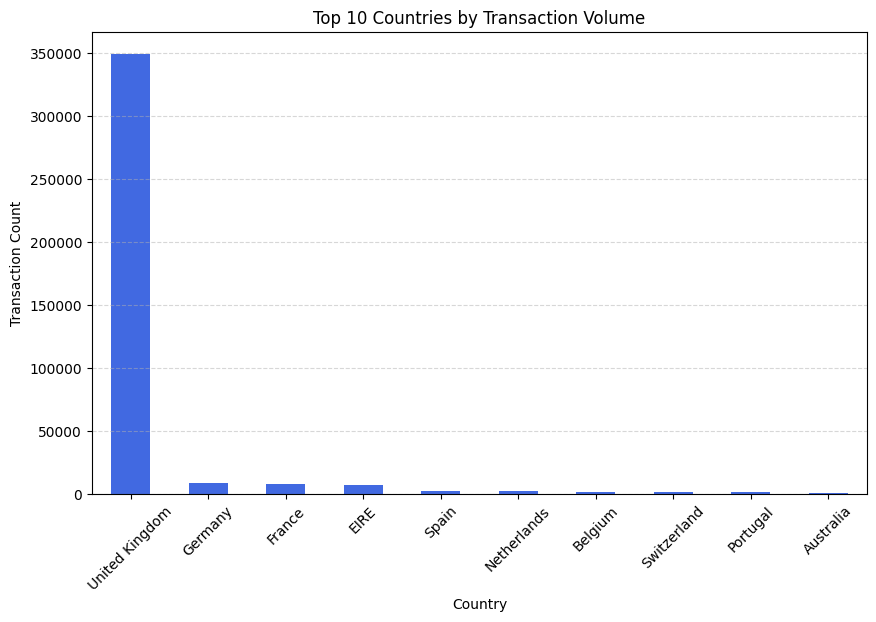

In [ ]:
plt.figure(figsize=(10,6))
country_transactions.head(10).plot(kind='bar',color='royalblue')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Top 10 Selling Products by Quantity sold

In [ ]:
top_products = (df.groupby('description')['quantity'].sum().
sort_values(ascending=False).head(10))
top_products

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


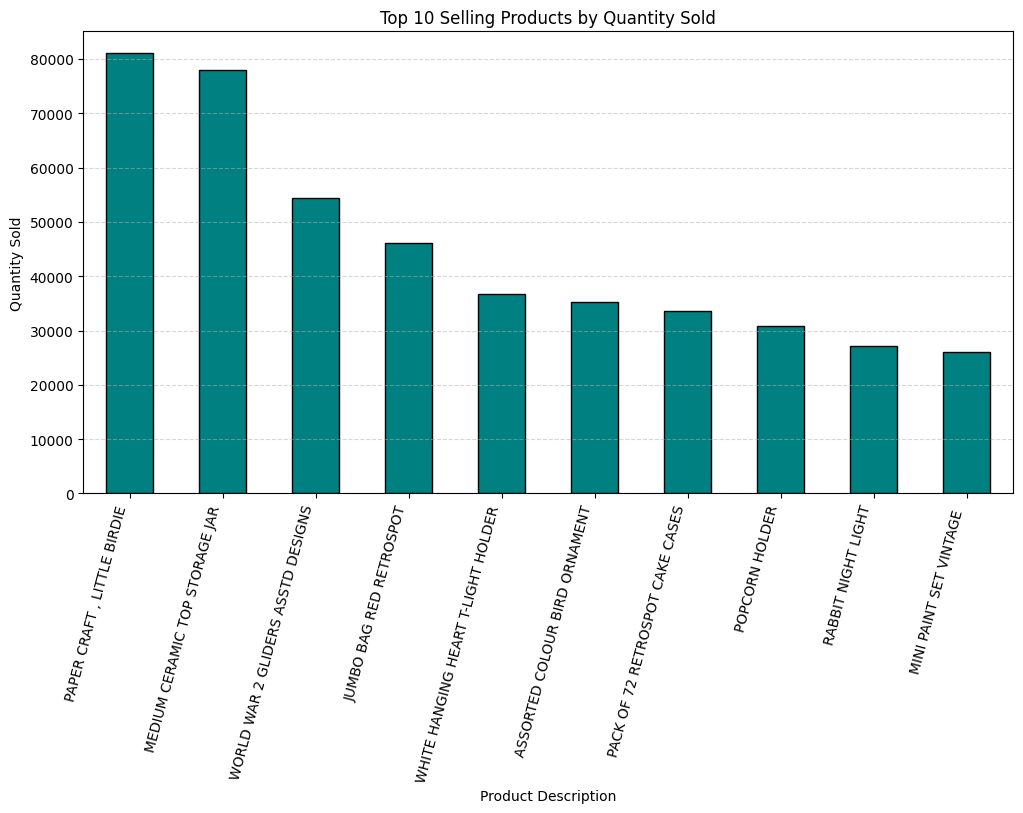

In [ ]:
plt.figure(figsize=(12,6))
top_products.plot(kind='bar',color='teal',edgecolor='black')
plt.title('Top 10 Selling Products by Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=75, ha = "right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Top 10 Countries by Revenue

In [ ]:
df["sales"] = df["quantity"] * df["unit_price"]

In [ ]:
country_sales = (df.groupby('country')['sales'].sum().
sort_values(ascending=False).head(10))
country_sales

,sales
country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


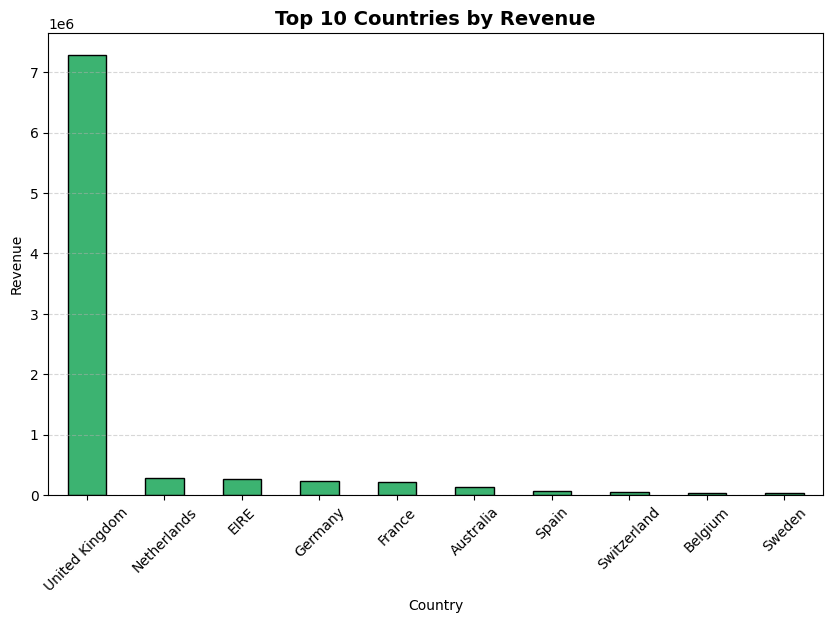

In [ ]:
plt.figure(figsize=(10,6))
country_sales.plot(kind='bar',color='mediumseagreen',edgecolor='black')
plt.title('Top 10 Countries by Revenue', fontsize=14,fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Top 10 Customers by Revenue

In [ ]:
top_customers = (df.groupby('customer_id')['sales'].sum().
sort_values(ascending=False).head(10))
top_customers

,sales
customer_id,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


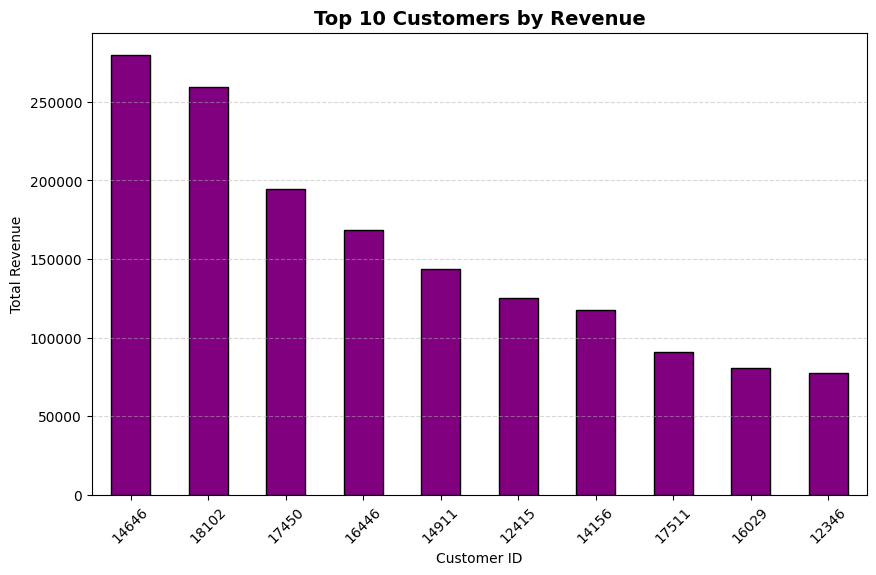

In [ ]:
plt.figure(figsize=(10,6))
top_customers.plot(kind='bar',color='purple',edgecolor='black')
plt.title('Top 10 Customers by Revenue', fontsize=14,fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()